In [60]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

trs = table.find_all('tr')

data = []
for tr in trs:

    th = tr.find('th').find('a')

    if not th: # None 값 제거
        continue

    point = th.text

    if tr.find_all('td'):
        temperature = tr.find_all('td')[4].text
        humidity = tr.find_all('td')[9].text

    # print([point, temperature, humidity])

    data.append([point, temperature, humidity])

data




99


[['강릉', '27.1', '33'],
 ['강진군', '26.8', '42'],
 ['강화', '17.9', '64'],
 ['거제', '22.8', '56'],
 ['거창', '29.3', '20'],
 ['경주시', '26.9', '33'],
 ['고산', '18.1', '76'],
 ['고창', '21.8', '37'],
 ['고창군', '24.7', '32'],
 ['고흥', '25.8', '42'],
 ['광양시', '26.7', '46'],
 ['광주', '26.8', '31'],
 ['구미', '28.5', '24'],
 ['군산', '19.4', '55'],
 ['금산', '26.6', '19'],
 ['김해시', '22.1', '59'],
 ['남원', '27.4', '32'],
 ['남해', '25.6', '47'],
 ['대관령', '23.3', '22'],
 ['대구', '29.9', '18'],
 ['대전', '26.7', '17'],
 ['동두천', '26.6', '31'],
 ['동해', '22.0', '48'],
 ['목포', '20.2', '50'],
 ['문경', '27.4', '23'],
 ['밀양', '29.4', '19'],
 ['백령도', '15.0', '70'],
 ['보령', '23.2', '42'],
 ['보성군', '25.4', '49'],
 ['보은', '26.0', '29'],
 ['봉화', '26.8', '23'],
 ['부산', '19.8', '72'],
 ['부안', '19.8', '53'],
 ['부여', '26.9', '26'],
 ['북강릉', '24.8', '35'],
 ['북부산', '23.9', '44'],
 ['북창원', '27.4', '40'],
 ['북춘천', '28.4', '20'],
 ['산청', '28.3', '34'],
 ['상주', '28.2', '24'],
 ['서귀포', '21.6', '69'],
 ['서산', '22.5', '35'],
 ['서울', '24.8', '41'

In [3]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [4]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
# pip install pandas
import pandas as pd # 데이터 처리

# csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
# df = pd.read_csv('weather.csv')
df = pd.read_csv('weather.csv', index_col='point')
df



,temperature,humidity
point,,
강릉,-0.2,54
강진군,-0.7,85
강화,-4.3,92
거제,0.6,65
거창,-3.5,77
...,...,...
합천,-2.5,71
해남,0.8,85
홍성,-0.6,99


In [5]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df

,temperature,humidity
point,,
서울,-2.1,74
인천,-1.7,73
대전,-0.8,73
대구,-1.4,69
광주,-0.2,88
부산,1.7,51
울산,-0.9,59


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '서울'),
  Text(1, 0, '인천'),
  Text(2, 0, '대전'),
  Text(3, 0, '대구'),
  Text(4, 0, '광주'),
  Text(5, 0, '부산'),
  Text(6, 0, '울산')])

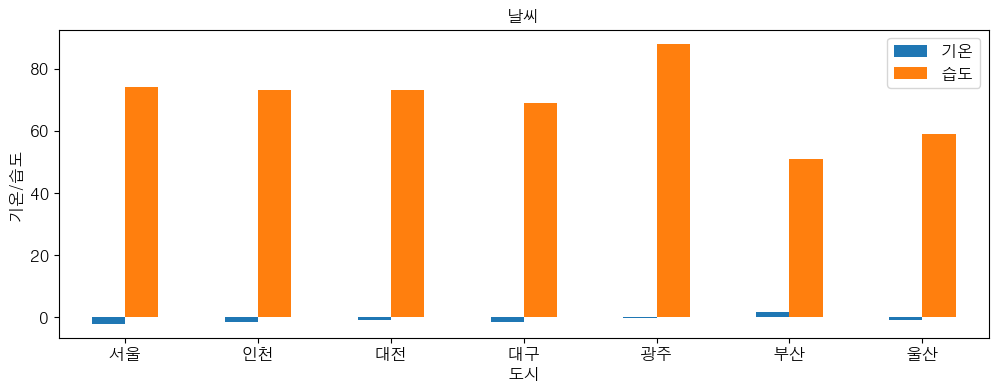

In [10]:
# Windows 한글 폰트 설정해야 함!
# pip install matplotlib
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_path = 'C:/Windows/Fonts/H2GTRM.TTF'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
# ax = city_df.plot() # 이 코드에서 속성을 하나씩 붙여 갈 것!
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정
plt.xticks(rotation=0)

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시할 경우
# plt.show()